# Phase 1: Exploratory Data Analysis

In [71]:
import os
import json

from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from shapely import wkt
from tqdm import tqdm
from matplotlib.colors import ListedColormap  
from matplotlib.patches import Patch 

# dataset path
DATA_ROOT = "/kaggle/input/datasets/azra41221/train-ert/train/train/"
IMAGES_DIR = os.path.join(DATA_ROOT, "images")
LABELS_DIR = os.path.join(DATA_ROOT, "labels")
TARGETS_DIR = os.path.join(DATA_ROOT, "targets")

os.makedirs('outputs', exist_ok = True)

## Step 1: Folder structure in dataset

In [72]:
for item in os.listdir(DATA_ROOT):
    full_path = os.path.join(DATA_ROOT, item)
    kind = "folder" if os.path.isdir(full_path) else "file"
    print(f"{item} - {kind}")

labels - folder
images - folder
targets - folder


## Step 2: Detailed structure of each folder

### Step 2.1: images

In [73]:
all_images_files = os.listdir(IMAGES_DIR)

print("Number of image files:", len(all_images_files))

print("Sample file names:")
for file in all_images_files[:3]:
    print(" ", file)

sample_image = Image.open(os.path.join(IMAGES_DIR, all_images_files[0]))
print("Image size:", sample_image.size)
print("Color mode:", sample_image.mode)

Number of image files: 5598
Sample file names:
  hurricane-harvey_00000128_post_disaster.png
  hurricane-harvey_00000260_pre_disaster.png
  hurricane-florence_00000026_post_disaster.png
Image size: (1024, 1024)
Color mode: RGB


### Step 2.2: labels

In [74]:
all_labels_files = os.listdir(LABELS_DIR)

print("Number of label files:", len(all_labels_files))

pre_label_count = len([file for file in all_labels_files if file.endswith("_pre_disaster.json")])
post_label_count = len([file for file in all_labels_files if file.endswith("_post_disaster.json")])

print("Pre-disaster labels:", pre_label_count)
print("Post-disaster labels:", post_label_count)

print("Sample pre files :")
for file in [f for f in all_labels_files if f.endswith("_pre_disaster.json")][:3]:
    print(" ", file)

print("Sample post files :")
for file in [f for f in all_labels_files if f.endswith("_post_disaster.json")][:3]:
    print(" ", file)

Number of label files: 5598
Pre-disaster labels: 2799
Post-disaster labels: 2799
Sample pre files :
  santa-rosa-wildfire_00000138_pre_disaster.json
  hurricane-harvey_00000041_pre_disaster.json
  hurricane-michael_00000020_pre_disaster.json
Sample post files :
  hurricane-matthew_00000295_post_disaster.json
  socal-fire_00000723_post_disaster.json
  midwest-flooding_00000033_post_disaster.json


### * key features of labels

In [75]:
sample_pre_path = os.path.join(LABELS_DIR, "mexico-earthquake_00000048_pre_disaster.json")

with open(sample_pre_path) as f:
    pre_label_data = json.load(f)

print("1. Key features:")
print(list(pre_label_data.keys()))

1. Key features:
['features', 'metadata']


In [76]:
# features
print("1.1 Features:")
print(list(pre_label_data["features"].keys()))

print("Type of 'xy':", type(pre_label_data["features"]["xy"]),
         "| number of buildings:", len(pre_label_data["features"]["xy"]))

1.1 Features:
['lng_lat', 'xy']
Type of 'xy': <class 'list'> | number of buildings: 1157


In [77]:
# metadata
print("1.2 Metadata:")
print(list(pre_label_data["metadata"].keys()))

1.2 Metadata:
['sensor', 'provider_asset_type', 'gsd', 'capture_date', 'off_nadir_angle', 'pan_resolution', 'sun_azimuth', 'sun_elevation', 'target_azimuth', 'disaster', 'disaster_type', 'catalog_id', 'original_width', 'original_height', 'width', 'height', 'id', 'img_name']


In [78]:
# first building
print("First building:")
print(json.dumps(pre_label_data["features"]["xy"][0], indent=2))

First building:
{
  "properties": {
    "feature_type": "building",
    "uid": "a13723d1-3da1-48ba-8e0b-47e5ca0342f3"
  },
  "wkt": "POLYGON ((1024 989.2819227286358, 1024 969.1753096578008, 971.17 1024, 989.75 1024, 1024 989.2819227286358))"
}


### Step 2.3: targets

In [79]:
all_targets_files = os.listdir(TARGETS_DIR)

print("Number of targets files:", len(all_targets_files))

print("Sample file names:")
for file in all_targets_files[:3]:
    print(" ", file)


Number of targets files: 5598
Sample file names:
  socal-fire_00000166_post_disaster_target.png
  mexico-earthquake_00000096_post_disaster_target.png
  socal-fire_00000271_post_disaster_target.png


## Step 3: building photos

### step 3.1: pre-disaster

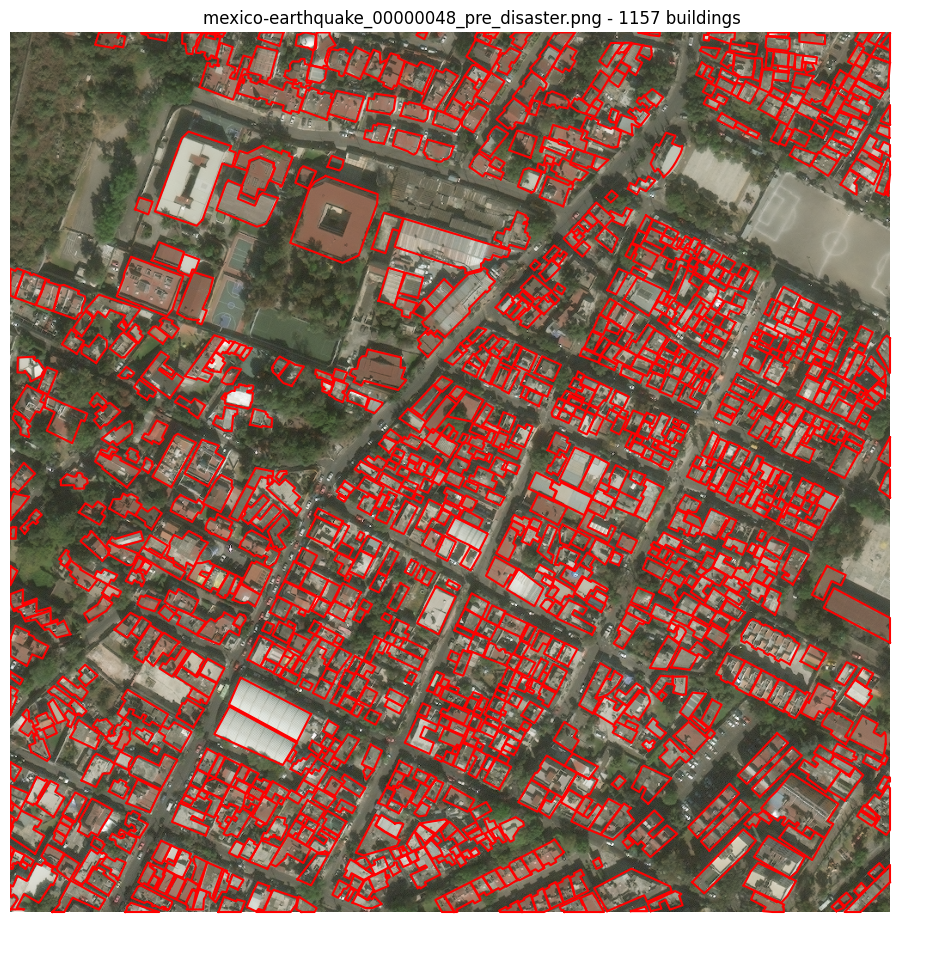

In [80]:
img_name = "mexico-earthquake_00000048_pre_disaster.png"
image = Image.open(os.path.join(IMAGES_DIR, img_name))

fig, ax = plt.subplots(1, 1, figsize=(12, 12))  
ax.imshow(image)                                

for building in pre_label_data["features"]["xy"]:
    polygon = wkt.loads(building["wkt"])        
    x, y = polygon.exterior.xy                  
    ax.plot(x, y, color="red", linewidth=1.5)   

ax.set_title(f"{img_name} - {len(pre_label_data['features']['xy'])} buildings")
ax.axis("off")                                  

plt.savefig(os.path.join("outputs", "pre_buildings_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()

### step 3.2: post-disaster - subtype

In [81]:
sample_post_path = os.path.join(LABELS_DIR, "mexico-earthquake_00000048_post_disaster.json")
with open(sample_post_path) as f:
    post_label_data = json.load(f)

for building in post_label_data["features"]["xy"][:3]:
    print(json.dumps(building["properties"], indent=2))

{
  "feature_type": "building",
  "subtype": "no-damage",
  "uid": "a13723d1-3da1-48ba-8e0b-47e5ca0342f3"
}
{
  "feature_type": "building",
  "subtype": "no-damage",
  "uid": "eddfdb51-4fe5-4c58-aa6d-29fd2e210450"
}
{
  "feature_type": "building",
  "subtype": "no-damage",
  "uid": "80f0f78a-6fa8-49eb-b5a2-0345422cab9f"
}


## Step 4: Distributions

In [82]:
## all post labeled
post_label_files = [file for file in all_labels_files if file.endswith("_post_disaster.json")]

post_labels = {}                                    
for file in tqdm(post_label_files):
    with open(os.path.join(LABELS_DIR, file)) as f:
        post_labels[file] = json.load(f)

print("Loaded post-disaster label files:", len(post_labels))

100%|██████████| 2799/2799 [00:07<00:00, 356.99it/s]

Loaded post-disaster label files: 2799


### Step 4.1: Damage Distribution

no-damage: 117426 (72.1%)
minor-damage: 14980 (9.2%)
major-damage: 14161 (8.7%)
destroyed: 13227 (8.1%)
un-classified: 2993 (1.8%)


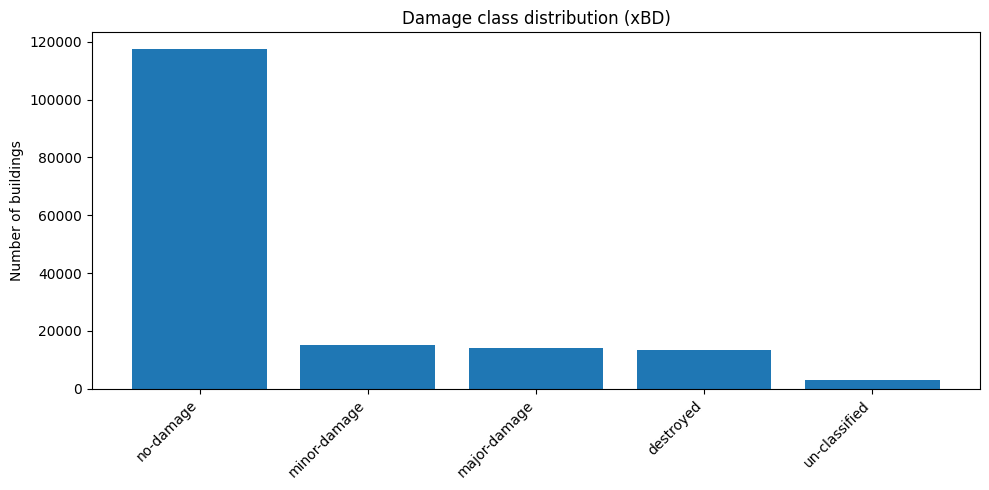

In [83]:
damage_counts = Counter()                  

for data in post_labels.values():                  
    for building in data["features"]["xy"]:      
        subtype = building["properties"].get("subtype", "unknown")  
        damage_counts[subtype] += 1

total_buildings = sum(damage_counts.values())
for subtype, count in damage_counts.most_common(): 
    print(f"{subtype}: {count} ({count / total_buildings * 100:.1f}%)")

labels, values = zip(*damage_counts.most_common())  
plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of buildings")
plt.title("Damage class distribution (xBD)")
plt.tight_layout()
plt.savefig(os.path.join("outputs", "damage_class_distribution.png"), dpi=150)
plt.show()

### Step 4.2: Disaster Distribution

disaster                         total   damaged    ratio
hurricane-harvey                 23014     11302    49.1%
hurricane-matthew                13939     10640    76.3%
hurricane-michael                22686      7866    34.7%
palu-tsunami                     31394      5538    17.6%
santa-rosa-wildfire              12950      3612    27.9%
socal-fire                       10475      1463    14.0%
hurricane-florence                6446      1431    22.2%
midwest-flooding                  8756       343     3.9%
mexico-earthquake                32271       130     0.4%
guatemala-volcano                  856        43     5.0%


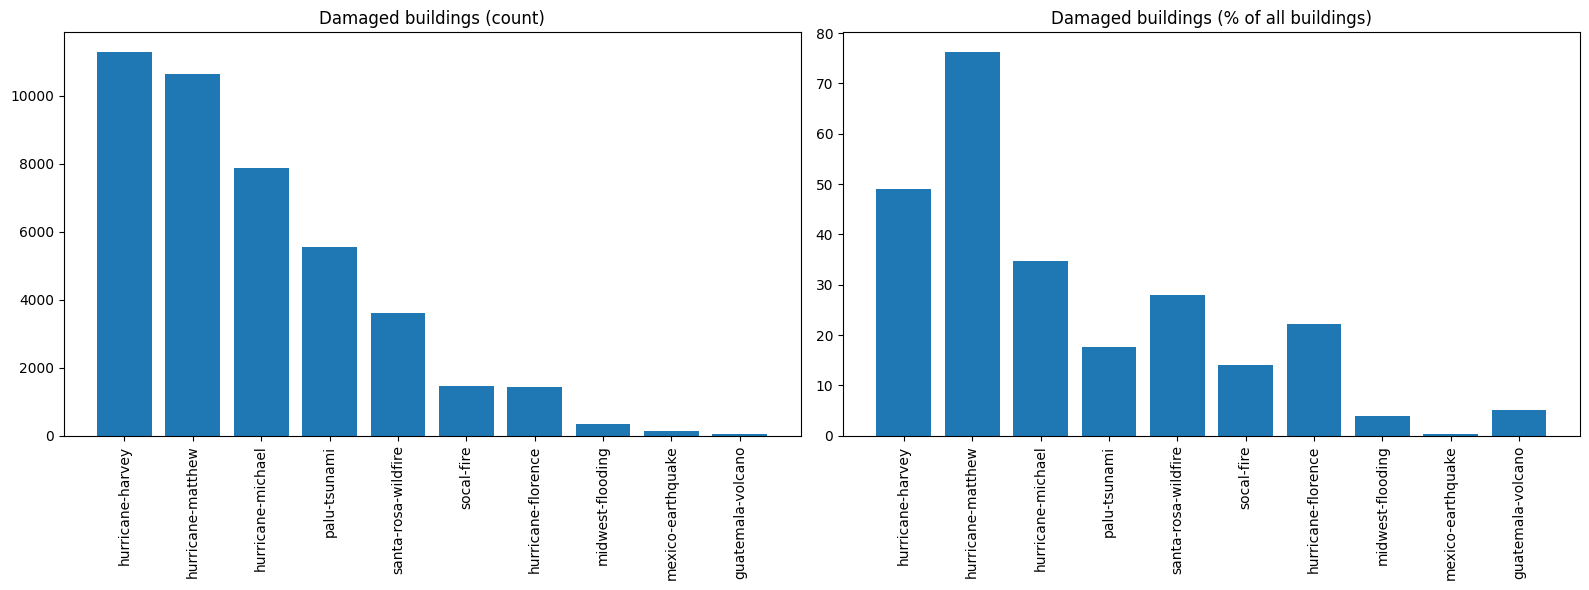

In [84]:
damaged_classes = ("minor-damage", "major-damage", "destroyed")

disaster_total = Counter()                          
disaster_damaged = Counter()                        

for file, data in post_labels.items():             
    disaster = file.split("_")[0]               
    for building in data["features"]["xy"]:     
        disaster_total[disaster] += 1            
        if building["properties"].get("subtype") in damaged_classes:
            disaster_damaged[disaster] += 1      

ranking = sorted(disaster_total, key=lambda d: disaster_damaged[d], reverse=True)

print(f"{'disaster':<28}{'total':>10}{'damaged':>10}{'ratio':>9}")
for disaster in ranking:
    total = disaster_total[disaster]
    damaged = disaster_damaged[disaster]
    print(f"{disaster:<28}{total:>10}{damaged:>10}{damaged / total * 100:>8.1f}%")

ratios = [disaster_damaged[d] / disaster_total[d] * 100 for d in ranking]
counts = [disaster_damaged[d] for d in ranking]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(ranking, counts)
axes[0].set_title("Damaged buildings (count)")
axes[1].bar(ranking, ratios)
axes[1].set_title("Damaged buildings (% of all buildings)")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)      
plt.tight_layout()
plt.savefig(os.path.join("outputs", "damage_by_disaster.png"), dpi=150, bbox_inches="tight")
plt.show()

### Step 4.3: Target Distribution

In [85]:
post_target_files = [file for file in all_targets_files if file.endswith("_post_disaster_target.png")]

pixel_counts = np.zeros(256, dtype=np.int64)      

for file in tqdm(post_target_files):
    mask = np.array(Image.open(os.path.join(TARGETS_DIR, file)))      
    pixel_counts += np.bincount(mask.ravel(), minlength=256)           

total_pixels = pixel_counts.sum()
for value, count in enumerate(pixel_counts):
    if count > 0:                                
        print(f"value {value}: {count} pixels ({count / total_pixels * 100:.2f}%)")

100%|██████████| 2799/2799 [00:27<00:00, 102.81it/s]

value 0: 2761163864 pixels (94.08%)
value 1: 128235816 pixels (4.37%)
value 2: 15935603 pixels (0.54%)
value 3: 20121556 pixels (0.69%)
value 4: 9507385 pixels (0.32%)


## Step 5: Pre-Post comparison

In [86]:
pre_mask_path = os.path.join(TARGETS_DIR, "hurricane-harvey_00000104_pre_disaster_target.png")
post_mask_path = os.path.join(TARGETS_DIR, "hurricane-harvey_00000104_post_disaster_target.png")

pre_mask = np.array(Image.open(pre_mask_path))
post_mask = np.array(Image.open(post_mask_path))

print("pre mask shape:", pre_mask.shape, "dtype:", pre_mask.dtype)
print("pre mask unique values:", np.unique(pre_mask))
print("post mask shape:", post_mask.shape, "dtype:", post_mask.dtype)
print("post mask unique values:", np.unique(post_mask))

unique, counts = np.unique(post_mask, return_counts=True)
for val, cnt in zip(unique, counts):
    print(f"value {val}: {cnt} piksel ({cnt/post_mask.size*100:.2f}%)")

pre mask shape: (1024, 1024) dtype: uint8
pre mask unique values: [0 1]
post mask shape: (1024, 1024) dtype: uint8
post mask unique values: [0 2 3]
value 0: 710444 piksel (67.75%)
value 2: 86643 piksel (8.26%)
value 3: 251489 piksel (23.98%)


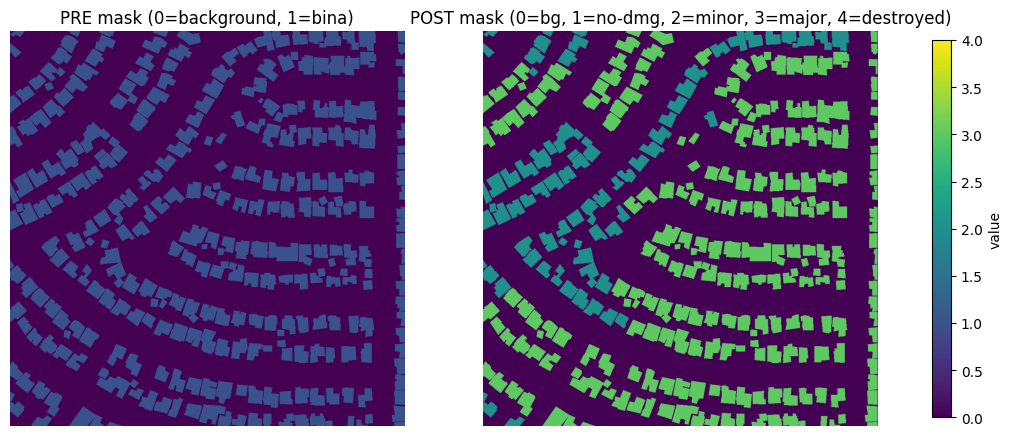

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(pre_mask, cmap="viridis", vmin=0, vmax=4)
axes[0].set_title("PRE mask (0=background, 1=bina)")
axes[0].axis("off")

im = axes[1].imshow(post_mask, cmap="viridis", vmin=0, vmax=4)
axes[1].set_title("POST mask (0=bg, 1=no-dmg, 2=minor, 3=major, 4=destroyed)")
axes[1].axis("off")

fig.colorbar(im, ax=axes, shrink=0.7, label="value")

output_path = os.path.join("outputs", "mexico-earthquake_00000048_pre_post_mask.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

## Step 6: Missing

In [88]:
missing = []                                   

for file in all_labels_files:
    if file.endswith("_pre_disaster.json"):
        base = file.replace("_pre_disaster.json", "")   
        expected = [
            (IMAGES_DIR, f"{base}_pre_disaster.png"),
            (IMAGES_DIR, f"{base}_post_disaster.png"),
            (LABELS_DIR, f"{base}_post_disaster.json"),
            (TARGETS_DIR, f"{base}_pre_disaster_target.png"),
            (TARGETS_DIR, f"{base}_post_disaster_target.png"),
        ]
        for folder, name in expected:
            if not os.path.exists(os.path.join(folder, name)):
                missing.append(name)

print("Number of missing files:", len(missing))

Number of missing files: 0
